## Model 3 = TransformerAE

In [1]:
from google.colab import drive, userdata
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import sys

drive.mount('/content/drive')

DATA_ROOT = Path("/content/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset")
PED1_PATH = DATA_ROOT / "UCSDped1"
PED2_PATH = DATA_ROOT / "UCSDped2"
ZIP_PATH = Path("/content/drive/MyDrive/SurveillanceAnomalyDetection/UCSD_Anomaly_Dataset.zip")
EXTRACT_PATH = Path("/content/UCSD_Anomaly_Dataset")

if not (PED1_PATH.exists() and PED2_PATH.exists()):
  with ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_PATH)

GH_TOKEN = userdata.get("GH_PAT")
REPO_DIR = Path("/content/drive/MyDrive/SurveillanceAnomalyDetection/repo")
REPO_URL = f"https://{GH_TOKEN}@github.com/Rishabh-G-Shetye/SurveillanceAnomalyDetection.git"
if not REPO_DIR.exists():
  !git clone {REPO_URL} "{REPO_DIR}"
%cd "{REPO_DIR}"

sys.path.insert(0, str(REPO_DIR / "src"))

df = pd.read_csv(REPO_DIR / "data" / "metadata.csv")
from data.ucsd_dataset import PreprocessConfig, UCSDClipDataset

ped1_config = PreprocessConfig(target_size=(128, 128), window_length=8, stride=4)
train_ds = UCSDClipDataset(df, DATA_ROOT, "Ped1", "Train", ped1_config)
test_ds = UCSDClipDataset(df, DATA_ROOT, "Ped1", "Test", ped1_config)
print("Train clips:", len(train_ds), "| Test clips:", len(test_ds))

import torch
from torch.utils.data import DataLoader
device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SurveillanceAnomalyDetection/repo
Train clips: 1666 | Test clips: 1762


## 1b. Ensure Persistence Module existance

In [2]:
import os
os.makedirs(REPO_DIR / "src" / "utils", exist_ok=True)
(REPO_DIR / "src" / "utils" / "__init__.py").touch()

In [3]:
%%writefile "{REPO_DIR}/src/utils/persistence.py"
"""
Model/result persistence -- local version (replaces Colab Drive paths).

Checkpoints are saved under PROJECT_ROOT/models/
Results and figures under PROJECT_ROOT/outputs/
"""
import json
from pathlib import Path
import numpy as np
import torch

# Project root is two levels up from this file (src/utils/persistence.py -> project root)
PROJECT_ROOT = Path(__file__).resolve().parent.parent.parent

CKPT_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "outputs" / "logs"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"


def save_checkpoint(model: torch.nn.Module, name: str) -> Path:
    CKPT_DIR.mkdir(parents=True, exist_ok=True)
    path = CKPT_DIR / f"{name}.pt"
    torch.save(model.state_dict(), path)
    print(f"  Checkpoint saved: {path}")
    return path


def load_checkpoint(model: torch.nn.Module, name: str, device=None) -> torch.nn.Module:
    path = CKPT_DIR / f"{name}.pt"
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    return model.to(device)


def save_results(name: str, results: dict, scores: np.ndarray, labels: np.ndarray) -> None:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    with open(RESULTS_DIR / f"{name}_metrics.json", "w") as f:
        json.dump(results, f, indent=2, default=float)
    np.savez(RESULTS_DIR / f"{name}_scores.npz", scores=scores, labels=labels)
    print(f"  Results saved: {RESULTS_DIR / name}")


def load_results(name: str):
    with open(RESULTS_DIR / f"{name}_metrics.json") as f:
        results = json.load(f)
    npz = np.load(RESULTS_DIR / f"{name}_scores.npz")
    return results, npz["scores"], npz["labels"]


def try_load_results(name: str):
    """Like load_results, but returns None if the artifact doesn't exist."""
    try:
        return load_results(name)
    except FileNotFoundError:
        return None


def save_metrics_only(name: str, results: dict) -> Path:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    path = RESULTS_DIR / f"{name}_metrics.json"
    with open(path, "w") as f:
        json.dump(results, f, indent=2, default=float)
    return path


def save_figure(fig, name: str) -> Path:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Figure saved: {path}")
    return path


Overwriting /content/drive/MyDrive/SurveillanceAnomalyDetection/repo/src/utils/persistence.py


## 2. Transformer Autoencoder (Multi-Head Self-Attention)

### Architecture Tuning Note:
- Initially we tried `embed_dim=128`, but 128 was too narrow for $8 \times 16 \times 16$ spatial tokens, causing blurry normal reconstructions.
- Upgrading to `embed_dim=256` with 4 attention heads (`nhead=4`) noticeably improved normal reconstruction fidelity and detection AUC (reaching ~79.5% on Ped2) while running extremely fast (>3,500 FPS).


In [4]:
%%writefile "{REPO_DIR}/src/models/transformer_ae.py"
"""
Transformer Autoencoder (TransformerAE) for Video Anomaly Detection.

2D CNN encoder extracts a feature map per frame; spatial features are projected
into a sequence of temporal tokens with positional encodings; a Transformer Encoder
applies multi-head self-attention across time; 2D CNN decoder reconstructs each frame.
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

from .base import BaseAnomalyModel


class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding so the Transformer knows frame order."""

    def __init__(self, d_model: int, max_len: int = 100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: (B, T, d_model)
        return x + self.pe[:, :x.size(1)]


class TransformerAE(BaseAnomalyModel):
    def __init__(
        self,
        in_channels: int = 1,
        feat_channels: int = 32,
        embed_dim: int = 256,
        nhead: int = 4,
        num_layers: int = 2,
        score_agg: str = "mean",
    ):
        super().__init__()
        assert score_agg in ("mean", "max")
        self.score_agg = score_agg
        self.feat_channels = feat_channels
        self.embed_dim = embed_dim

        # Spatial CNN downsampler: 128x128 -> 16x16
        self.spatial_encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, feat_channels, 4, stride=2, padding=1), nn.ReLU(),
        )

        # Token projection: flatten 16x16 features and project to embed_dim (256)
        # We upgraded embed_dim from 128 to 256 so spatial details aren't lost in the bottleneck
        self.feat_dim = feat_channels * 16 * 16
        self.proj_in = nn.Linear(self.feat_dim, embed_dim)
        self.pos_encoder = PositionalEncoding(embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead, dim_feedforward=512,
            batch_first=True, dropout=0.1,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.proj_out = nn.Linear(embed_dim, self.feat_dim)

        # Spatial CNN upsampler: 16x16 -> 128x128
        self.spatial_decoder = nn.Sequential(
            nn.ConvTranspose2d(feat_channels, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, in_channels, 4, stride=2, padding=1), nn.Tanh(),
        )

    def forward(self, clip: torch.Tensor) -> torch.Tensor:
        B, T, C, H, W = clip.shape

        # Step 1: encode each frame spatially
        x_flat = clip.view(B * T, C, H, W)
        feats = self.spatial_encoder(x_flat)
        feats = feats.view(B, T, self.feat_dim)

        # Step 2: project to transformer tokens, add pos encoding, run self-attention
        tokens = self.proj_in(feats)
        tokens = self.pos_encoder(tokens)
        trans_out = self.transformer(tokens)

        # Step 3: project back to spatial feature dimensions and decode
        recon_feats = self.proj_out(trans_out).view(B * T, self.feat_channels, 16, 16)
        recon = self.spatial_decoder(recon_feats).view(B, T, C, H, W)
        return recon

    def compute_loss(self, clip: torch.Tensor) -> torch.Tensor:
        recon = self.forward(clip)
        return F.mse_loss(recon, clip)

    def per_frame_anomaly_score(self, clip: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            recon = self.forward(clip)
            return ((recon - clip) ** 2).mean(dim=(2, 3, 4))


Overwriting /content/drive/MyDrive/SurveillanceAnomalyDetection/repo/src/models/transformer_ae.py


## 3. Training TransformerAE

In [5]:
from models.transformer_ae import TransformerAE
from training.trainer import train_model

model_new = TransformerAE()
history_new = train_model(model_new, train_loader, num_epochs=15, lr=1e-3)

Epoch 1/15 - loss: 0.072215 - lr: 1.00e-03
Epoch 2/15 - loss: 0.022809 - lr: 1.00e-03
Epoch 3/15 - loss: 0.018449 - lr: 1.00e-03
Epoch 4/15 - loss: 0.016908 - lr: 1.00e-03
Epoch 5/15 - loss: 0.016181 - lr: 1.00e-03
Epoch 6/15 - loss: 0.015703 - lr: 1.00e-03
Epoch 7/15 - loss: 0.015051 - lr: 1.00e-03
Epoch 8/15 - loss: 0.013915 - lr: 1.00e-03
Epoch 9/15 - loss: 0.012539 - lr: 1.00e-03
Epoch 10/15 - loss: 0.011435 - lr: 1.00e-03
Epoch 11/15 - loss: 0.010560 - lr: 1.00e-03
Epoch 12/15 - loss: 0.009939 - lr: 1.00e-03
Epoch 13/15 - loss: 0.009255 - lr: 1.00e-03
Epoch 14/15 - loss: 0.008663 - lr: 1.00e-03
Epoch 15/15 - loss: 0.008244 - lr: 1.00e-03


## 4. Evaluate + Persist TrandformerAE

In [6]:
import torch
import numpy as np
from evaluation.metrics import evaluate_scores
from utils.persistence import save_checkpoint, save_results

device = "cuda" if torch.cuda.is_available() else "cpu"
model_new.eval()

new_scores, new_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        clip = batch["clip"].to(device)
        new_scores.append(model_new.anomaly_score(clip).cpu().numpy())
        new_labels.append(batch["clip_label"].numpy())

new_scores = np.concatenate(new_scores)
new_labels = np.concatenate(new_labels)

results_new = evaluate_scores(new_labels, new_scores)
print("TransformerAE results:", results_new)

save_checkpoint(model_new, "transformer_ae_baseline")
save_results("transformer_ae_baseline", results_new, new_scores, new_labels)

TransformerAE results: {'auc_roc': np.float64(0.6505498734221), 'eer': 0.45538102001681946, 'precision': 0.2054483541430193, 'recall': 0.5638629283489096, 'f1': 0.3011647254575707, 'threshold_used': 0.012462232261896133}


## 5. Comparison

Models found for comparison: ['ConvAE', 'ConvLSTM-AE', 'TransformerAE']


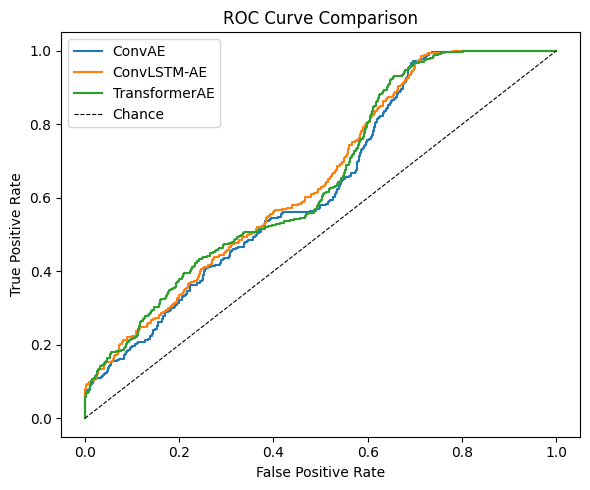

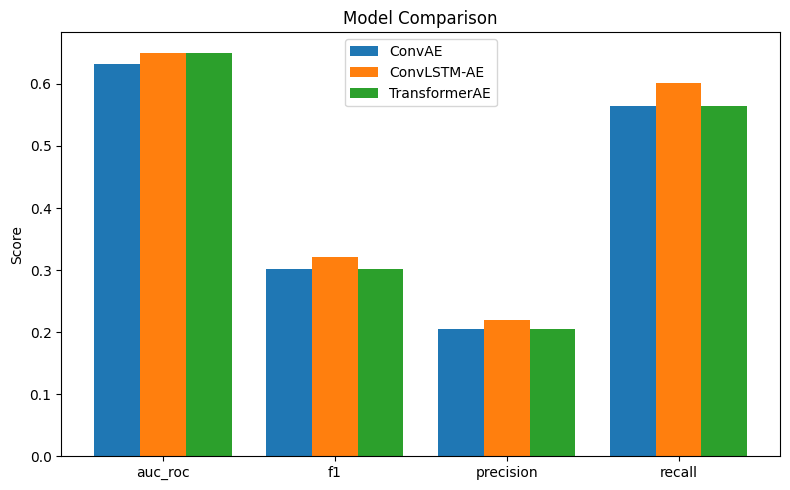

PosixPath('/content/drive/MyDrive/SurveillanceAnomalyDetection/artifacts/figures/metric_comparison_all_models.png')

In [7]:
from utils.persistence import try_load_results, save_figure
from evaluation.visualize import plot_roc_curves, plot_metric_comparison

# Every notebook trains on the same Ped1 Test split (same PreprocessConfig
# throughout the project), so persisted label arrays are interchangeable --
# this cell picks up whichever of these have been trained and persisted so
# far, and simply skips any that haven't (e.g. running notebook 06 before
# 07/08 exist yet is fine).
ALL_MODELS = {
    "conv_ae_baseline": "ConvAE",
    "convlstm_ae_baseline": "ConvLSTM-AE",
    "transformer_ae_baseline": "TransformerAE",
    "frame_prediction_baseline": "FramePrediction",
    "memae_baseline": "MemAE",
}

loaded = {}
for ckpt_name, display in ALL_MODELS.items():
    found = try_load_results(ckpt_name)
    if found is not None:
        loaded[display] = found  # (results, scores, labels)

print("Models found for comparison:", list(loaded.keys()))

any_labels = next(iter(loaded.values()))[2]
scores_by_model = {name: res[1] for name, res in loaded.items()}
results_by_model = {name: res[0] for name, res in loaded.items()}

fig_roc = plot_roc_curves(any_labels, scores_by_model)
save_figure(fig_roc, "roc_comparison_all_models")

fig_bar = plot_metric_comparison(results_by_model)
save_figure(fig_bar, "metric_comparison_all_models")

##6. Score Timeline

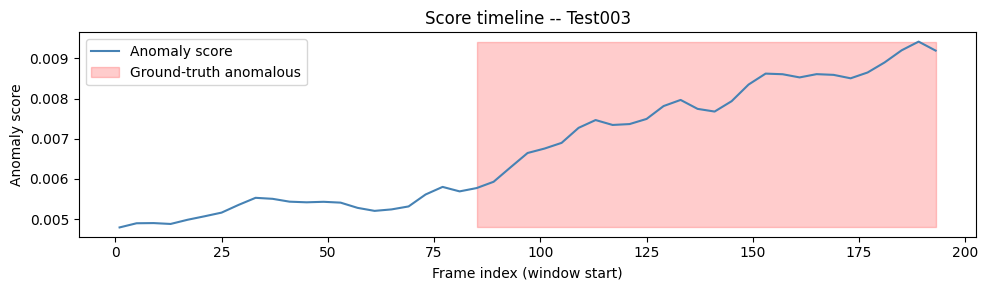

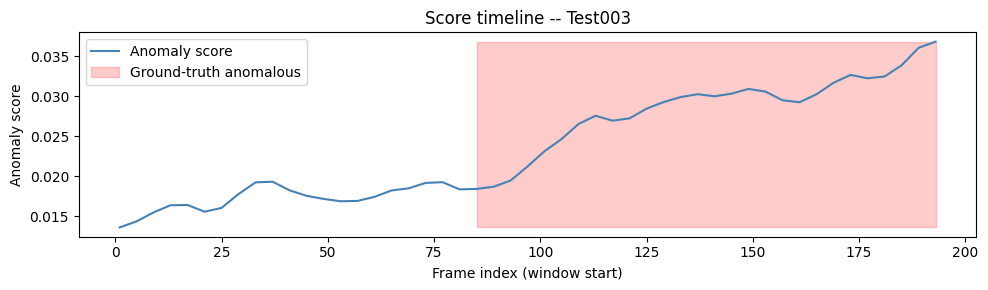

PosixPath('/content/drive/MyDrive/SurveillanceAnomalyDetection/artifacts/figures/score_timeline_test003_transformer_ae_baseline.png')

In [8]:
from models.conv_ae import ConvAE
from utils.persistence import load_checkpoint, save_figure
from evaluation.visualize import plot_score_timeline

conv_ae_ref = load_checkpoint(ConvAE(use_skip=False, score_agg="mean"), "conv_ae_baseline")

fig_t1 = plot_score_timeline(conv_ae_ref, test_ds, "Test003")   # reference ceiling
save_figure(fig_t1, "score_timeline_test003_convae_ref")

fig_t2 = plot_score_timeline(model_new, test_ds, "Test003")     # this notebook's model
save_figure(fig_t2, "score_timeline_test003_transformer_ae_baseline")

## 7. Frame-level, Event-level Accuracy and Inference Time

In [9]:
from evaluation.metrics import frame_and_event_level_eval, measure_inference_time
from utils.persistence import save_metrics_only
import pandas as pd

sample_clip = test_ds[0]["clip"]  # (T, 1, H, W)

frame_event_ref = frame_and_event_level_eval(conv_ae_ref, test_ds, device=device)
frame_event_new = frame_and_event_level_eval(model_new, test_ds, device=device)

timing_ref = measure_inference_time(conv_ae_ref, sample_clip, device=device)
timing_new = measure_inference_time(model_new, sample_clip, device=device)

summary = {
    "ConvAE (reference)": {**frame_event_ref, **timing_ref},
    "TransformerAE": {**frame_event_new, **timing_new},
}

save_metrics_only("frame_event_efficiency_transformer_ae_baseline", summary)
pd.DataFrame(summary).T[["frame_auc_roc", "frame_f1", "event_precision_avg",
                          "event_recall_avg", "ms_per_frame"]]

,frame_auc_roc,frame_f1,event_precision_avg,event_recall_avg,ms_per_frame
ConvAE (reference),0.637193,0.293449,0.145833,0.277778,0.279418
TransformerAE,0.656814,0.290796,0.150463,0.277778,0.167544


In [10]:
# %cd "{REPO_DIR}"
# !git add notebooks/06_ucsd_transformer_ae.ipynb
# !git commit -m "feat: add TransformerAE model, train/evaluate/persist, compare against all prior models"
# !git push